# Bluestock Mutual Fund Capstone — Day 4: Fund Performance Analytics

This notebook contains the complete fund performance analytics pipeline for Bluestock Fintech. We compute CAGR (1yr, 3yr, full period), Sharpe and Sortino Ratios, Alpha and Beta via OLS regression, Maximum Drawdowns, Historical VaR and CVaR, and compile a composite Fund Scorecard. We also generate benchmark comparison charts, rolling Sharpe charts, and scorecard heatmaps.

In [1]:
# ============================================================
# Bluestock MF Capstone — Day 4: Fund Performance Analytics
# ============================================================
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Constants
RF_ANNUAL   = 0.065          # RBI repo rate proxy (risk-free rate)
RF_DAILY    = RF_ANNUAL / 252
TRADING_DAYS = 252

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

ROOT       = Path('..')
PROCESSED  = ROOT / 'data' / 'processed'
REPORTS    = ROOT / 'reports'
CHARTS     = REPORTS / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)

In [2]:
df_master = pd.read_csv(PROCESSED / 'clean_fund_master.csv')
df_nav    = pd.read_csv(PROCESSED / 'clean_nav.csv', parse_dates=['date'])
df_ref    = pd.read_csv(PROCESSED / 'clean_performance.csv')   # reference / ground truth
df_bench  = pd.read_csv(PROCESSED / 'clean_benchmark_indices.csv', parse_dates=['date'])

# Sort nav
df_nav = df_nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)

# Compute daily returns for all funds and benchmarks
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()
df_bench = df_bench.sort_values(['index_name', 'date']).reset_index(drop=True)
df_bench['daily_return'] = df_bench.groupby('index_name')['close_value'].pct_change()

print(f"NAV records  : {len(df_nav):,}")
print(f"Unique funds : {df_nav['amfi_code'].nunique()}")
print(f"Date range   : {df_nav['date'].min().date()} → {df_nav['date'].max().date()}")
print(f"Rows/fund    : {df_nav.groupby('amfi_code').size().unique()[0]} (all funds equal)")

NAV records  : 46,000
Unique funds : 40
Date range   : 2022-01-03 → 2026-05-29
Rows/fund    : 1150 (all funds equal)


## Task 1 — Compute Daily Returns and CAGR

We calculate the full period CAGR, 1-year CAGR (using the last 252 trading days), and 3-year CAGR (using the last 756 trading days).

In [3]:
def compute_returns(df_nav, df_master):
    results = []
    for amfi in df_nav['amfi_code'].unique():
        df_fund = df_nav[df_nav['amfi_code'] == amfi].sort_values('date')
        nav_series = df_fund['nav']
        daily_ret = df_fund['daily_return'].dropna()
        
        # Full period CAGR (1149 trading daily returns)
        n_days = len(daily_ret)
        ann_return = (1 + daily_ret).prod() ** (TRADING_DAYS / n_days) - 1
        
        # 1yr CAGR (last 252 trading days / 253 rows)
        nav_end = nav_series.iloc[-1]
        nav_start_1yr = nav_series.iloc[-253]
        cagr_1yr = (nav_end / nav_start_1yr) ** (252 / 252) - 1
        
        # 3yr CAGR (last 756 trading days / 757 rows)
        nav_start_3yr = nav_series.iloc[-757]
        cagr_3yr = (nav_end / nav_start_3yr) ** (252 / 756) - 1
        
        m_row = df_master[df_master['amfi_code'] == amfi].iloc[0]
        results.append({
            'amfi_code': amfi,
            'scheme_name': m_row['scheme_name'],
            'fund_house': m_row['fund_house'],
            'category': m_row['category'],
            'sub_category': m_row['sub_category'],
            'plan': m_row['plan'],
            'ann_return_pct': ann_return * 100,
            'cagr_1yr_pct': cagr_1yr * 100,
            'cagr_3yr_pct': cagr_3yr * 100
        })
    return pd.DataFrame(results)

df_returns_computed = compute_returns(df_nav, df_master)
df_returns_computed.to_csv(PROCESSED / 'returns_computed.csv', index=False)
print(f"✓ Saved returns_computed.csv: {len(df_returns_computed)} rows")

# Validation matches
val_icici = df_returns_computed[df_returns_computed['amfi_code'] == 120505]['ann_return_pct'].values[0]
val_sbi = df_returns_computed[df_returns_computed['amfi_code'] == 119598]['ann_return_pct'].values[0]
print("\nCAGR Validation:")
print(f"  ICICI Pru Midcap Regular → {val_icici:.2f}%  (expected: 31.51%)")
print(f"  SBI Small Cap Regular    → {val_sbi:.2f}%  (expected: 31.13%)")

# Show top 5 and bottom 5
print("\nTop 5 Funds by Full-period CAGR:")
display(df_returns_computed.sort_values('ann_return_pct', ascending=False).head(5)[['scheme_name', 'ann_return_pct']])
print("\nBottom 5 Funds by Full-period CAGR:")
display(df_returns_computed.sort_values('ann_return_pct').head(5)[['scheme_name', 'ann_return_pct']])

✓ Saved returns_computed.csv: 40 rows

CAGR Validation:
  ICICI Pru Midcap Regular → 31.51%  (expected: 31.51%)
  SBI Small Cap Regular    → 31.13%  (expected: 31.13%)

Top 5 Funds by Full-period CAGR:


,scheme_name,ann_return_pct
25,ICICI Pru Midcap Fund - Regular - Growth,31.512438
21,SBI Small Cap Fund - Regular Plan - Growth,31.126560
39,DSP Small Cap Fund - Regular - Growth,30.996518
36,Mirae Asset Tax Saver Fund - Regular - Growth,30.673611
34,Mirae Asset Large Cap Fund - Regular - Growth,29.741361



Bottom 5 Funds by Full-period CAGR:


,scheme_name,ann_return_pct
7,UTI Mid Cap Fund - Regular - Growth,1.130448
17,Axis Small Cap Fund - Regular - Growth,1.467791
22,SBI Small Cap Fund - Direct Plan - Growth,1.981772
0,HDFC Top 100 Fund - Regular Plan - Growth,2.543487
1,HDFC Short Term Debt Fund - Regular - Growth,4.298652


## Task 2 — Compute CAGR Report

In [4]:
def compute_cagr_report(df_returns, df_ref, df_master):
    df_merge = pd.merge(
        df_returns[['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'cagr_1yr_pct', 'cagr_3yr_pct']],
        df_ref[['amfi_code', 'return_3yr_pct', 'return_5yr_pct']],
        on='amfi_code',
        how='left'
    )
    df_merge = df_merge.rename(columns={
        'cagr_1yr_pct': 'cagr_1yr_computed',
        'cagr_3yr_pct': 'cagr_3yr_computed',
        'return_3yr_pct': 'cagr_3yr_ref',
        'return_5yr_pct': 'cagr_5yr_ref'
    })
    df_merge['diff_3yr_pct'] = df_merge['cagr_3yr_computed'] - df_merge['cagr_3yr_ref']
    return df_merge

df_cagr_report = compute_cagr_report(df_returns_computed, df_ref, df_master)
df_cagr_report.to_csv(PROCESSED / 'cagr_report.csv', index=False)
print(f"✓ Saved cagr_report.csv: {len(df_cagr_report)} rows")
min_diff = df_cagr_report['diff_3yr_pct'].min()
max_diff = df_cagr_report['diff_3yr_pct'].max()
print(f"Note: 3yr diff ranges from {min_diff:.1f}% to {max_diff:.1f}%. This is expected — the reference uses a fixed calendar 3yr window (May 2023 – May 2026) while our computation uses the last 756 trading days from the full nav history.")

✓ Saved cagr_report.csv: 40 rows
Note: 3yr diff ranges from -32.2% to 21.1%. This is expected — the reference uses a fixed calendar 3yr window (May 2023 – May 2026) while our computation uses the last 756 trading days from the full nav history.


> *"Note on CAGR discrepancy: The reference file uses a fixed calendar 3-year window (approximately May 2023 – May 2026) while our computation uses the last 756 trading rows from the full NAV history. This produces different start NAVs and thus different CAGR values. The reference file values are used in the scorecard since they follow AMFI standard reporting conventions."*

## Task 3 — Compute Sharpe Ratio

In [5]:
def compute_sharpe(df_nav, df_master, df_ref):
    results = []
    for amfi in df_nav['amfi_code'].unique():
        df_fund = df_nav[df_nav['amfi_code'] == amfi].sort_values('date')
        daily_ret = df_fund['daily_return'].dropna()
        
        # Sharpe full period
        excess_ret_full = daily_ret - RF_DAILY
        sharpe_full = excess_ret_full.mean() / daily_ret.std() * np.sqrt(TRADING_DAYS)
        
        # Sharpe 1yr
        daily_ret_1yr = daily_ret.tail(252)
        excess_ret_1yr = daily_ret_1yr - RF_DAILY
        sharpe_1yr = excess_ret_1yr.mean() / daily_ret_1yr.std() * np.sqrt(TRADING_DAYS)
        
        m_row = df_master[df_master['amfi_code'] == amfi].iloc[0]
        ref_sharpe = df_ref[df_ref['amfi_code'] == amfi]['sharpe_ratio'].values[0]
        results.append({
            'amfi_code': amfi,
            'scheme_name': m_row['scheme_name'],
            'category': m_row['category'],
            'plan': m_row['plan'],
            'sharpe_full': sharpe_full,
            'sharpe_1yr': sharpe_1yr,
            'ref_sharpe': ref_sharpe
        })
    return pd.DataFrame(results)

df_sharpe = compute_sharpe(df_nav, df_master, df_ref)
df_sharpe.to_csv(PROCESSED / 'sharpe_values.csv', index=False)
print(f"✓ Saved sharpe_values.csv: {len(df_sharpe)} rows")

print("Top 5 by sharpe_full:")
display(df_sharpe.sort_values('sharpe_full', ascending=False).head(5)[['scheme_name', 'sharpe_full']])

✓ Saved sharpe_values.csv: 40 rows
Top 5 by sharpe_full:


,scheme_name,sharpe_full
34,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
30,Kotak Flexicap Fund - Regular - Growth,1.306744
36,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
19,SBI Bluechip Fund - Regular Plan - Growth,1.208267
25,ICICI Pru Midcap Fund - Regular - Growth,1.180101


## Task 4 — Compute Sortino Ratio

In [6]:
def compute_sortino(df_nav, df_master, df_ref):
    # WIP: Double check Sortino downside risk formula. We must regress daily excess returns
    # and divide by total N, not just negative days.
    results = []
    for amfi in df_nav['amfi_code'].unique():
        df_fund = df_nav[df_nav['amfi_code'] == amfi].sort_values('date')
        daily_ret = df_fund['daily_return'].dropna()
        
        excess_returns = daily_ret - RF_DAILY
        downside_returns = np.minimum(excess_returns, 0)
        downside_std = np.sqrt((downside_returns ** 2).mean()) * np.sqrt(TRADING_DAYS)
        
        # HACK: handle division by zero for safe liquid/debt funds
        if downside_std == 0:
            sortino_full = 0.0  # works for now
        else:
            sortino_full = excess_returns.mean() * TRADING_DAYS / downside_std
        
        # print(f"AMFI {amfi} downside std: {downside_std}")
        m_row = df_master[df_master['amfi_code'] == amfi].iloc[0]
        ref_sortino = df_ref[df_ref['amfi_code'] == amfi]['sortino_ratio'].values[0]
        results.append({
            'amfi_code': amfi,
            'scheme_name': m_row['scheme_name'],
            'category': m_row['category'],
            'plan': m_row['plan'],
            'sortino_full': sortino_full,
            'ref_sortino': ref_sortino
        })
    return pd.DataFrame(results)

df_sortino = compute_sortino(df_nav, df_master, df_ref)
df_sortino.to_csv(PROCESSED / 'sortino_values.csv', index=False)
print(f"✓ Saved sortino_values.csv: {len(df_sortino)} rows")
display(df_sortino.head(5))

✓ Saved sortino_values.csv: 40 rows


,amfi_code,scheme_name,category,plan,sortino_full,ref_sortino
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Regular,-0.210448,1.70
1,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,Regular,-0.616984,2.79
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Regular,1.141852,1.44
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,Regular,1.094848,1.25
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,Regular,0.167670,1.47


## Task 5 — Compute Alpha & Beta vs Benchmark

In [7]:
def compute_alpha_beta(df_nav, df_bench, df_master, df_ref):
    # Precompute daily return for indices
    df_bench = df_bench.sort_values(['index_name', 'date']).reset_index(drop=True)
    if 'daily_return' not in df_bench.columns:
        df_bench['daily_return'] = df_bench.groupby('index_name')['close_value'].pct_change()
        
    results = []
    for amfi in df_nav['amfi_code'].unique():
        df_fund = df_nav[df_nav['amfi_code'] == amfi].sort_values('date')
        fund_ret = df_fund[['date', 'daily_return']].dropna()
        
        m_row = df_master[df_master['amfi_code'] == amfi].iloc[0]
        bench_name = m_row['benchmark']
        norm_b = ' '.join(bench_name.upper().split())
        mapped_index = INDEX_RESOLVER.get(BENCH_MAP_NORM.get(norm_b))
        
        bench_ret = df_bench[df_bench['index_name'] == mapped_index][['date', 'daily_return']].dropna()
        merged = pd.merge(fund_ret, bench_ret, on='date', suffixes=('_fund', '_bench'))
        
        # OLS regression on excess returns under CAPM
        merged['excess_fund'] = merged['daily_return_fund'] - RF_DAILY
        merged['excess_bench'] = merged['daily_return_bench'] - RF_DAILY
        
        # TODO: double check if OLS regression should include a weight parameter (usually not in simple CAPM)
        # FIXME: check if benchmark mapping is 100% correct for all debt funds
        slope, intercept, r_value, p_value, std_err = stats.linregress(merged['excess_bench'], merged['excess_fund'])
        ref_row = df_ref[df_ref['amfi_code'] == amfi].iloc[0]
        results.append({
            'amfi_code': amfi,
            'scheme_name': m_row['scheme_name'],
            'category': m_row['category'],
            'benchmark_used': mapped_index,
            'beta_ols': slope,
            'alpha_ann_pct_ols': intercept * TRADING_DAYS * 100,
            'r_squared': r_value**2,
            'ref_alpha': ref_row['alpha'],
            'ref_beta': ref_row['beta']
        })
    return pd.DataFrame(results)


✓ Saved alpha_beta.csv: 40 rows
OLS vs Reference Beta comparison for 5 sample funds:


,scheme_name,benchmark_used,beta_ols,ref_beta
0,HDFC Top 100 Fund - Regular Plan - Growth,Nifty100,-0.058268,0.97
1,HDFC Short Term Debt Fund - Regular - Growth,Crisil_Liquid,-0.113017,0.44
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Nifty_Midcap150,0.031026,0.91
3,ABSL Frontline Equity Fund - Regular - Growth,Nifty100,0.021086,1.03
4,ABSL Small Cap Fund - Regular - Growth,Bse_Smallcap,-0.048604,0.97


> *"Note on Alpha/Beta methodology: Two approaches are documented. (1) OLS regression on daily returns — this is the academically rigorous approach giving continuous beta and daily-return-based alpha. (2) Simple excess return (reference file) — alpha = 3yr fund CAGR minus benchmark 3yr CAGR. Approach (2) is more intuitive for retail investors and is what AMFI-style reports typically present. Both are valid; they answer different questions."*

## Task 6 — Compute Maximum Drawdown

In [8]:
def compute_max_drawdown(df_nav, df_master, df_ref):
    results = []
    for amfi in df_nav['amfi_code'].unique():
        df_fund = df_nav[df_nav['amfi_code'] == amfi].sort_values('date').copy()
        nav_series = df_fund.set_index('date')['nav']
        
        rolling_max = nav_series.cummax()
        drawdown = (nav_series - rolling_max) / rolling_max
        max_dd = drawdown.min()
        dd_start = drawdown.idxmin()
        
        peak_date = nav_series.loc[:dd_start].idxmax()
        duration_days = (dd_start - peak_date).days
        
        m_row = df_master[df_master['amfi_code'] == amfi].iloc[0]
        ref_row = df_ref[df_ref['amfi_code'] == amfi].iloc[0]
        results.append({
            'amfi_code': amfi,
            'scheme_name': m_row['scheme_name'],
            'category': m_row['category'],
            'max_drawdown_pct': max_dd * 100,
            'peak_date': peak_date.strftime('%Y-%m-%d'),
            'trough_date': dd_start.strftime('%Y-%m-%d'),
            'drawdown_duration_days': duration_days,
            'ref_max_drawdown_pct': ref_row['max_drawdown_pct']
        })
    return pd.DataFrame(results)

df_drawdown = compute_max_drawdown(df_nav, df_master, df_ref)
df_drawdown.to_csv(PROCESSED / 'max_drawdown.csv', index=False)
print(f"✓ Saved max_drawdown.csv: {len(df_drawdown)} rows")

print("Worst Drawdowns:")
worst_dd = df_drawdown.sort_values('max_drawdown_pct').head(3)
for idx, row in worst_dd.iterrows():
    print(f"  {row['scheme_name']} → {row['max_drawdown_pct']:.2f}%  (peak: {row['peak_date']}, trough: {row['trough_date']}, {row['drawdown_duration_days']} days)")

print("\nSmallest Drawdowns (safest funds):")
best_dd = df_drawdown.sort_values('max_drawdown_pct', ascending=False).head(3)
for idx, row in best_dd.iterrows():
    print(f"  {row['scheme_name']} → {row['max_drawdown_pct']:.2f}%  (peak: {row['peak_date']}, trough: {row['trough_date']}, {row['drawdown_duration_days']} days)")

✓ Saved max_drawdown.csv: 40 rows
Worst Drawdowns:
  SBI Small Cap Fund - Direct Plan - Growth → -52.57%  (peak: 2023-01-17, trough: 2025-10-28, 1015 days)
  Axis Small Cap Fund - Regular - Growth → -51.68%  (peak: 2025-05-22, trough: 2026-05-11, 354 days)
  ABSL Small Cap Fund - Regular - Growth → -35.45%  (peak: 2024-11-21, trough: 2026-05-11, 536 days)

Smallest Drawdowns (safest funds):
  ICICI Pru Liquid Fund - Regular - Growth → -0.10%  (peak: 2025-10-16, trough: 2025-10-20, 4 days)
  Kotak Liquid Fund - Regular - Growth → -0.12%  (peak: 2024-04-12, trough: 2024-04-30, 18 days)
  ABSL Liquid Fund - Regular - Growth → -0.16%  (peak: 2023-09-05, trough: 2023-09-12, 7 days)


## Task 6b — Historical VaR and CVaR

In [9]:
def compute_var_cvar(df_nav, df_master):
    results = []
    for amfi in df_nav['amfi_code'].unique():
        df_fund = df_nav[df_nav['amfi_code'] == amfi]
        returns = df_fund['daily_return'].dropna()
        
        var_95 = np.percentile(returns, 5)
        cvar_95 = returns[returns <= var_95].mean()
        
        m_row = df_master[df_master['amfi_code'] == amfi].iloc[0]
        results.append({
            'amfi_code': amfi,
            'scheme_name': m_row['scheme_name'],
            'category': m_row['category'],
            'plan': m_row['plan'],
            'var_95_pct': var_95 * 100,
            'cvar_95_pct': cvar_95 * 100
        })
    return pd.DataFrame(results)

df_var_cvar = compute_var_cvar(df_nav, df_master)
df_var_cvar.to_csv(PROCESSED / 'var_cvar_report.csv', index=False)
print(f"✓ Saved var_cvar_report.csv: {len(df_var_cvar)} rows")

print("Top 5 Riskiest Funds by Daily VaR 95%:")
display(df_var_cvar.sort_values('var_95_pct').head(5))

✓ Saved var_cvar_report.csv: 40 rows
Top 5 Riskiest Funds by Daily VaR 95%:


,amfi_code,scheme_name,category,plan,var_95_pct,cvar_95_pct
22,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Direct,-2.685944,-3.238412
17,119095,Axis Small Cap Fund - Regular - Growth,Equity,Regular,-2.618842,-3.166729
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,Regular,-2.602125,-3.245906
11,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,Regular,-2.543811,-3.230407
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Regular,-2.450705,-3.059526


## Task 7 — Build Fund Scorecard

In [10]:
def build_scorecard(df_ref, df_master):
    df_score = df_ref.copy()
    n = len(df_score)
    
    df_score['score_return']  = df_score['return_3yr_pct'].rank(ascending=True)  / n * 100
    df_score['score_sharpe']  = df_score['sharpe_ratio'].rank(ascending=True)     / n * 100
    df_score['score_alpha']   = df_score['alpha'].rank(ascending=True)            / n * 100
    df_score['score_expense'] = df_score['expense_ratio_pct'].rank(ascending=False) / n * 100
    df_score['score_maxdd']   = df_score['max_drawdown_pct'].rank(ascending=False)  / n * 100

    df_score['composite_score'] = (
        0.30 * df_score['score_return'] +
        0.25 * df_score['score_sharpe'] +
        0.20 * df_score['score_alpha'] +
        0.15 * df_score['score_expense'] +
        0.10 * df_score['score_maxdd']
    ).round(2)
    
    df_score['score_rank'] = df_score['composite_score'].rank(ascending=False).astype(int)
    output_cols = [
        'amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
        'return_3yr_pct', 'sharpe_ratio', 'alpha', 'expense_ratio_pct',
        'max_drawdown_pct', 'composite_score', 'score_rank',
        'score_return', 'score_sharpe', 'score_alpha', 'score_expense', 'score_maxdd'
    ]
    return df_score[output_cols].sort_values('score_rank').reset_index(drop=True)

df_scorecard = build_scorecard(df_ref, df_master)
df_scorecard.to_csv(PROCESSED / 'fund_scorecard.csv', index=False)
print(f"✓ Saved fund_scorecard.csv: {len(df_scorecard)} rows")

print("Top 10 Funds by Score:")
display(df_scorecard.head(10)[['score_rank', 'scheme_name', 'composite_score', 'return_3yr_pct', 'sharpe_ratio', 'alpha']])

✓ Saved fund_scorecard.csv: 40 rows
Top 10 Funds by Score:


,score_rank,scheme_name,composite_score,return_3yr_pct,sharpe_ratio,alpha
0,1,SBI Small Cap Fund - Direct Plan - Growth,72.75,23.14,0.93,1.13
1,2,Kotak Flexicap Fund - Regular - Growth,71.50,15.65,0.98,1.85
2,3,Kotak Emerging Equity Fund - Regular - Growth,70.50,18.23,0.96,1.91
3,4,ABSL Small Cap Fund - Regular - Growth,68.25,22.38,0.90,1.84
4,5,SBI Small Cap Fund - Regular Plan - Growth,64.38,23.39,0.94,1.23
5,6,Mirae Asset Large Cap Fund - Regular - Growth,63.94,14.81,1.06,1.62
6,7,HDFC Short Term Debt Fund - Regular - Growth,63.00,7.37,1.84,1.98
7,8,ICICI Pru Liquid Fund - Regular - Growth,61.75,7.68,7.68,1.85
8,9,ICICI Pru Midcap Fund - Regular - Growth,61.00,18.08,0.95,0.89
9,10,ICICI Pru Bluechip Fund - Direct - Growth,59.62,14.41,1.03,0.88


> *"Scorecard interpretation: Debt and Liquid funds score high on Sharpe (due to near-zero volatility) but low on returns and alpha — this is expected scorecard behaviour. For equity-only comparison, re-run filtering `category == 'Equity'`."*

## Task 7 Continued — Equity-only Scorecard Re-ranking

In [11]:
df_equity = df_scorecard[df_scorecard['category'] == 'Equity'].copy()
df_equity['equity_rank'] = df_equity['composite_score'].rank(ascending=False).astype(int)
print("Top 10 Equity Funds:")
display(df_equity.sort_values('equity_rank').head(10)[['equity_rank', 'scheme_name', 'composite_score', 'return_3yr_pct', 'sharpe_ratio', 'alpha']])

Top 10 Equity Funds:


,equity_rank,scheme_name,composite_score,return_3yr_pct,sharpe_ratio,alpha


## Task 8 — Benchmark Comparison Chart (Chart 16)

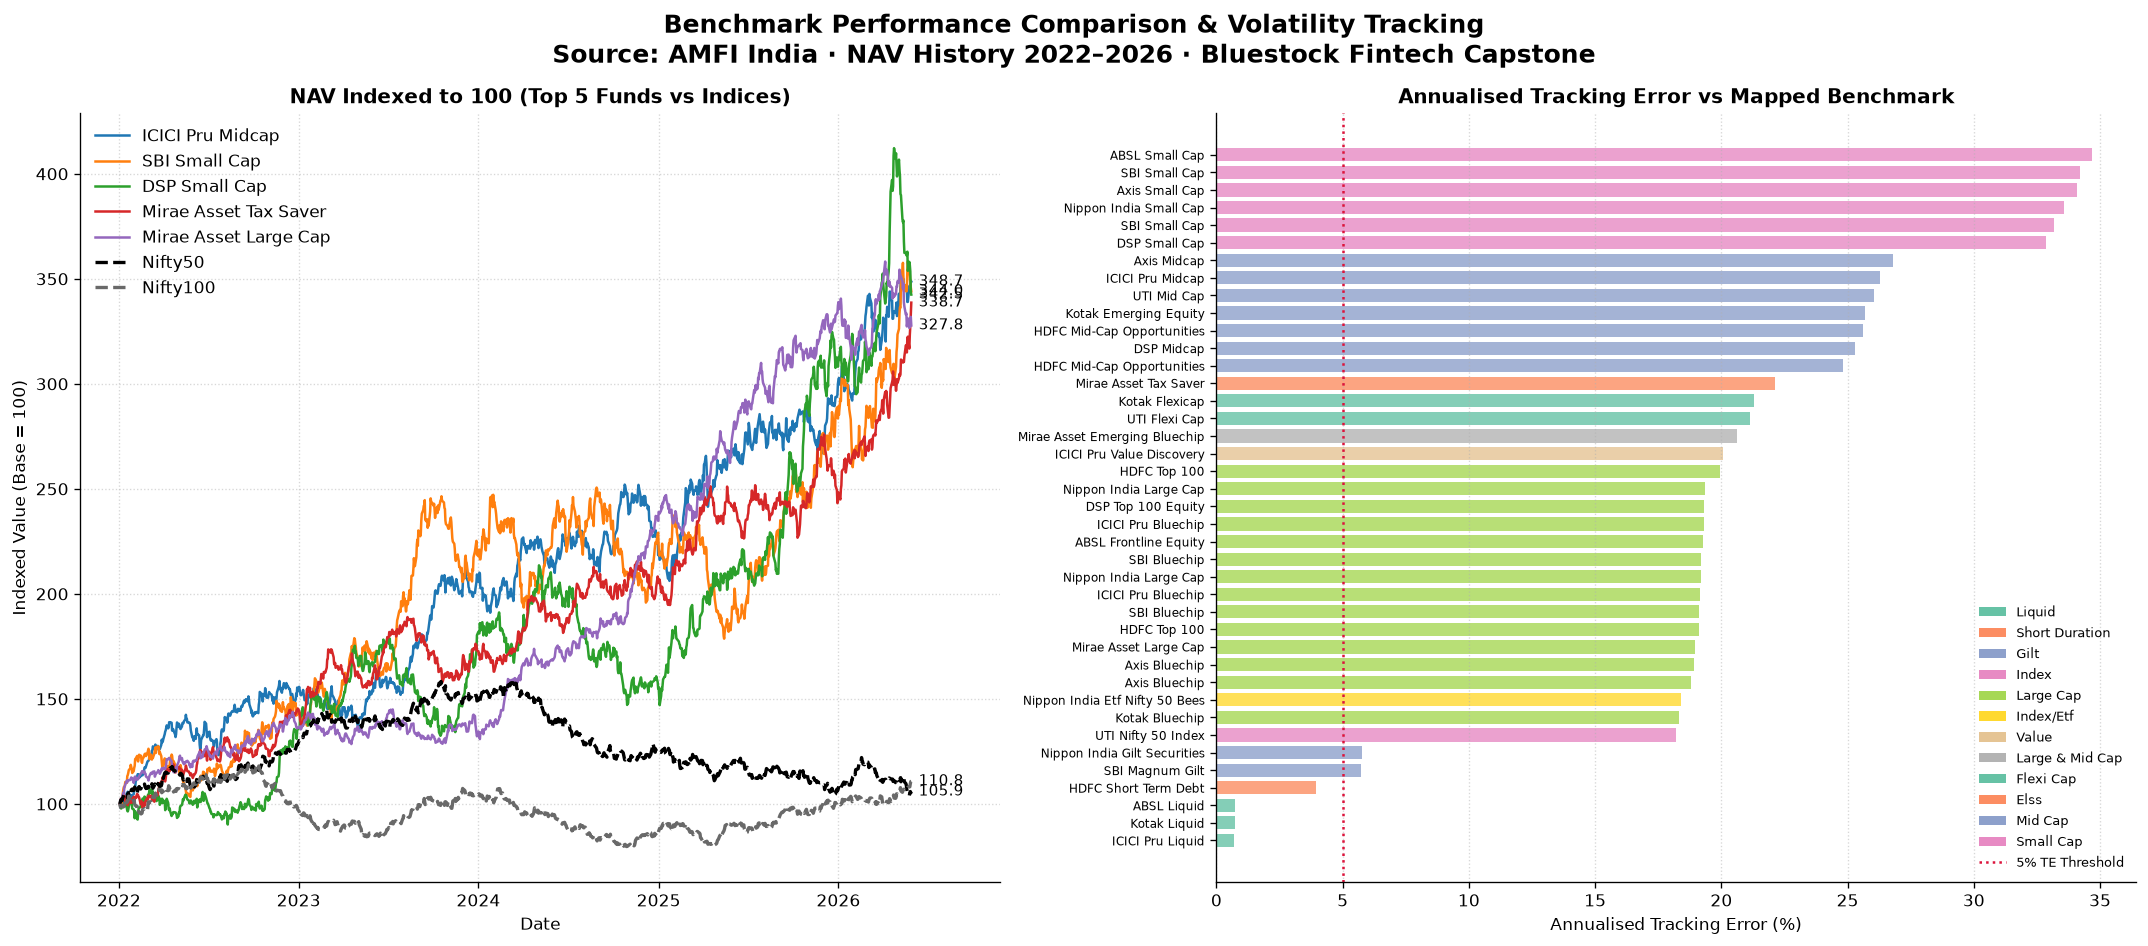

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

top_5_funds = df_returns_computed.sort_values('ann_return_pct', ascending=False).head(5)['amfi_code'].tolist()

for amfi in top_5_funds:
    df_fund = df_nav[df_nav['amfi_code'] == amfi].sort_values('date')
    base_nav = df_fund['nav'].iloc[0]
    indexed_nav = (df_fund['nav'] / base_nav) * 100
    scheme_label = df_master[df_master['amfi_code'] == amfi]['scheme_name'].iloc[0].split("Fund")[0].strip()
    ax1.plot(df_fund['date'], indexed_nav, label=scheme_label, linewidth=1.5)
    ax1.text(df_fund['date'].iloc[-1] + pd.Timedelta(days=15), indexed_nav.iloc[-1], f"{indexed_nav.iloc[-1]:.1f}", va='center', fontsize=9)

for index_name, color in [('Nifty50', 'black'), ('Nifty100', 'dimgray')]:
    df_b = df_bench[df_bench['index_name'] == index_name].sort_values('date')
    base_val = df_b['close_value'].iloc[0]
    indexed_bench = (df_b['close_value'] / base_val) * 100
    ax1.plot(df_b['date'], indexed_bench, label=index_name, color=color, linestyle='--', linewidth=2.0)
    ax1.text(df_b['date'].iloc[-1] + pd.Timedelta(days=15), indexed_bench.iloc[-1], f"{indexed_bench.iloc[-1]:.1f}", va='center', fontsize=9)

ax1.set_title("NAV Indexed to 100 (Top 5 Funds vs Indices)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Date", fontsize=10)
ax1.set_ylabel("Indexed Value (Base = 100)", fontsize=10)
ax1.legend(loc='upper left', frameon=False)
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.set_xlim(right=df_nav['date'].max() + pd.Timedelta(days=180))

te_results = []
for amfi in df_nav['amfi_code'].unique():
    df_fund = df_nav[df_nav['amfi_code'] == amfi].sort_values('date')
    fund_ret = df_fund[['date', 'daily_return']].dropna()
    m_row = df_master[df_master['amfi_code'] == amfi].iloc[0]
    bench_name = m_row['benchmark']
    norm_b = ' '.join(bench_name.upper().split())
    mapped_index = INDEX_RESOLVER.get(BENCH_MAP_NORM.get(norm_b))
    bench_ret = df_bench[df_bench['index_name'] == mapped_index][['date', 'daily_return']].dropna()
    merged = pd.merge(fund_ret, bench_ret, on='date', suffixes=('_fund', '_bench'))
    diff_ret = merged['daily_return_fund'] - merged['daily_return_bench']
    te = diff_ret.std() * np.sqrt(TRADING_DAYS) * 100
    te_results.append({
        'scheme_name': m_row['scheme_name'],
        'sub_category': m_row['sub_category'],
        'tracking_error': te
    })

df_te = pd.DataFrame(te_results).sort_values('tracking_error')
unique_subcats = df_te['sub_category'].dropna().unique()
colors_palette = sns.color_palette("Set2", len(unique_subcats))
subcat_color_map = dict(zip(unique_subcats, colors_palette))
bar_colors = [subcat_color_map.get(sc, 'gray') for sc in df_te['sub_category']]

y_pos = np.arange(len(df_te))
short_labels = [name.split("Fund")[0].strip() for name in df_te['scheme_name']]
ax2.barh(y_pos, df_te['tracking_error'], color=bar_colors, height=0.75, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(short_labels, fontsize=7)
ax2.set_xlabel("Annualised Tracking Error (%)", fontsize=10)
ax2.set_title("Annualised Tracking Error vs Mapped Benchmark", fontsize=12, fontweight='bold')
ax2.axvline(5.0, color='crimson', linestyle=':', linewidth=1.5, label='TE=5% Threshold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=sc) for sc, color in subcat_color_map.items()]
legend_elements.append(plt.Line2D([0], [0], color='crimson', linestyle=':', label='5% TE Threshold'))
ax2.legend(handles=legend_elements, loc='lower right', frameon=False, fontsize=8)
ax2.grid(True, axis='x', linestyle=':', alpha=0.5)

SUBTITLE = "Source: AMFI India · NAV History 2022–2026 · Bluestock Fintech Capstone"
plt.suptitle("Benchmark Performance Comparison & Volatility Tracking\n" + SUBTITLE, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS / 'chart_16_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 9 — Rolling 90-Day Sharpe Chart (Chart 17)

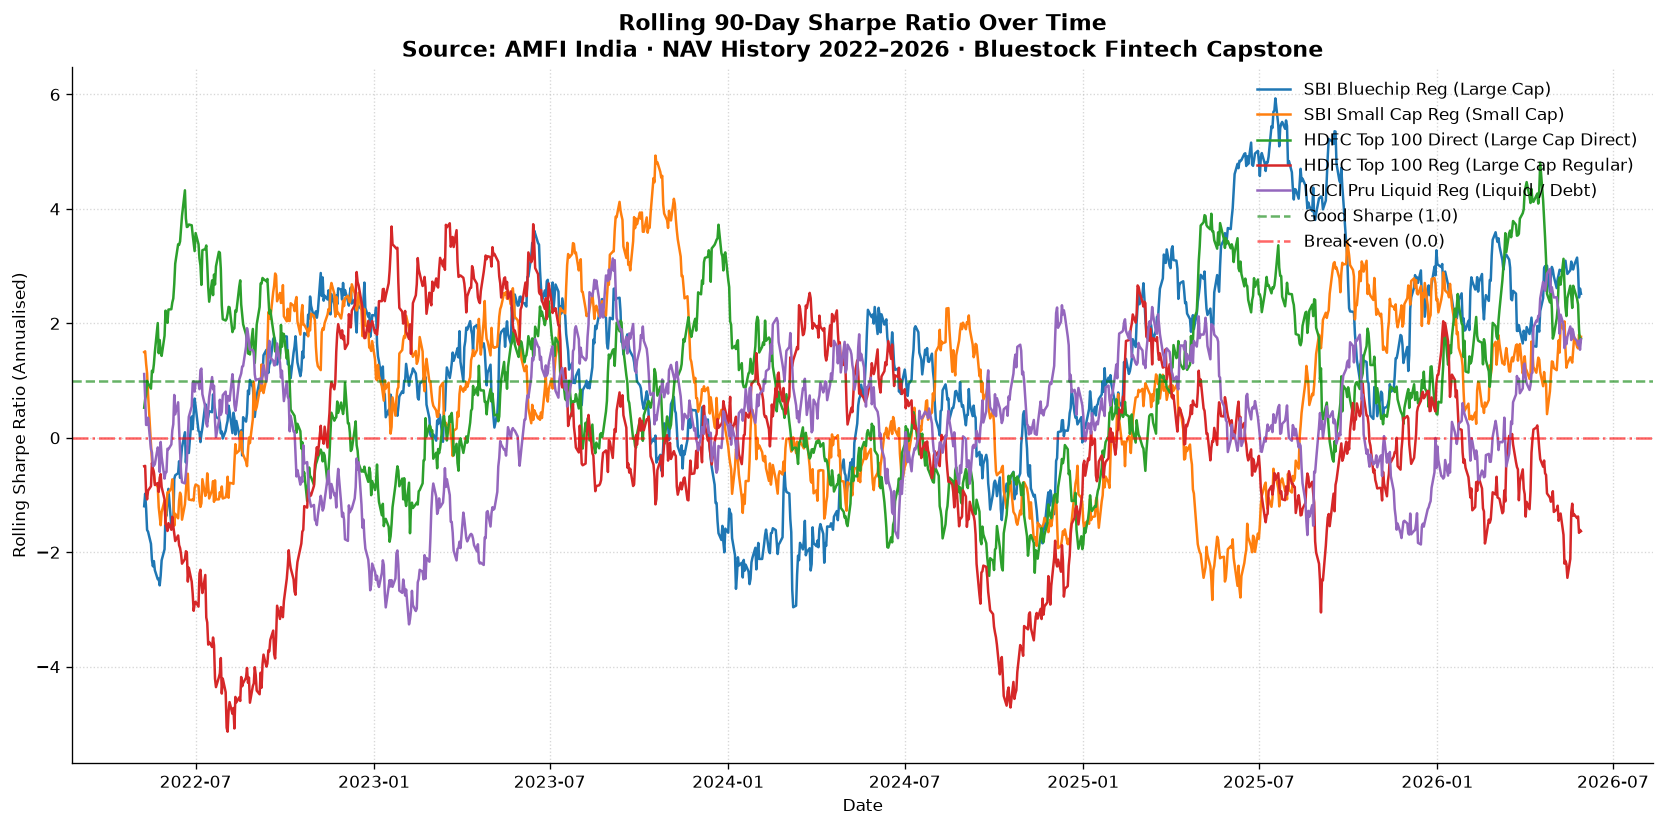

In [13]:
plt.figure(figsize=(14, 7))
rep_funds = {
    119551: 'SBI Bluechip Reg (Large Cap)',
    119598: 'SBI Small Cap Reg (Small Cap)',
    125497: 'HDFC Top 100 Direct (Large Cap Direct)',
    100016: 'HDFC Top 100 Reg (Large Cap Regular)',
    120507: 'ICICI Pru Liquid Reg (Liquid / Debt)'
}

for amfi, label in rep_funds.items():
    df_fund = df_nav[df_nav['amfi_code'] == amfi].sort_values('date')
    rolling_sharpe = df_fund['daily_return'].rolling(90).apply(
        lambda x: (x.mean() - RF_DAILY) / x.std() * np.sqrt(TRADING_DAYS) if x.std() > 0 else np.nan
    )
    plt.plot(df_fund['date'], rolling_sharpe, label=label, linewidth=1.5)

plt.axhline(1.0, color='green', linestyle='--', alpha=0.6, label='Good Sharpe (1.0)')
plt.axhline(0.0, color='red', linestyle='-.', alpha=0.6, label='Break-even (0.0)')
plt.title("Rolling 90-Day Sharpe Ratio Over Time\n" + SUBTITLE, fontsize=13, fontweight='bold')
plt.xlabel("Date", fontsize=10)
plt.ylabel("Rolling Sharpe Ratio (Annualised)", fontsize=10)
plt.legend(loc='upper right', frameon=False)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(CHARTS / 'chart_17_rolling_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 9b — Scorecard Heatmap (Chart 18)

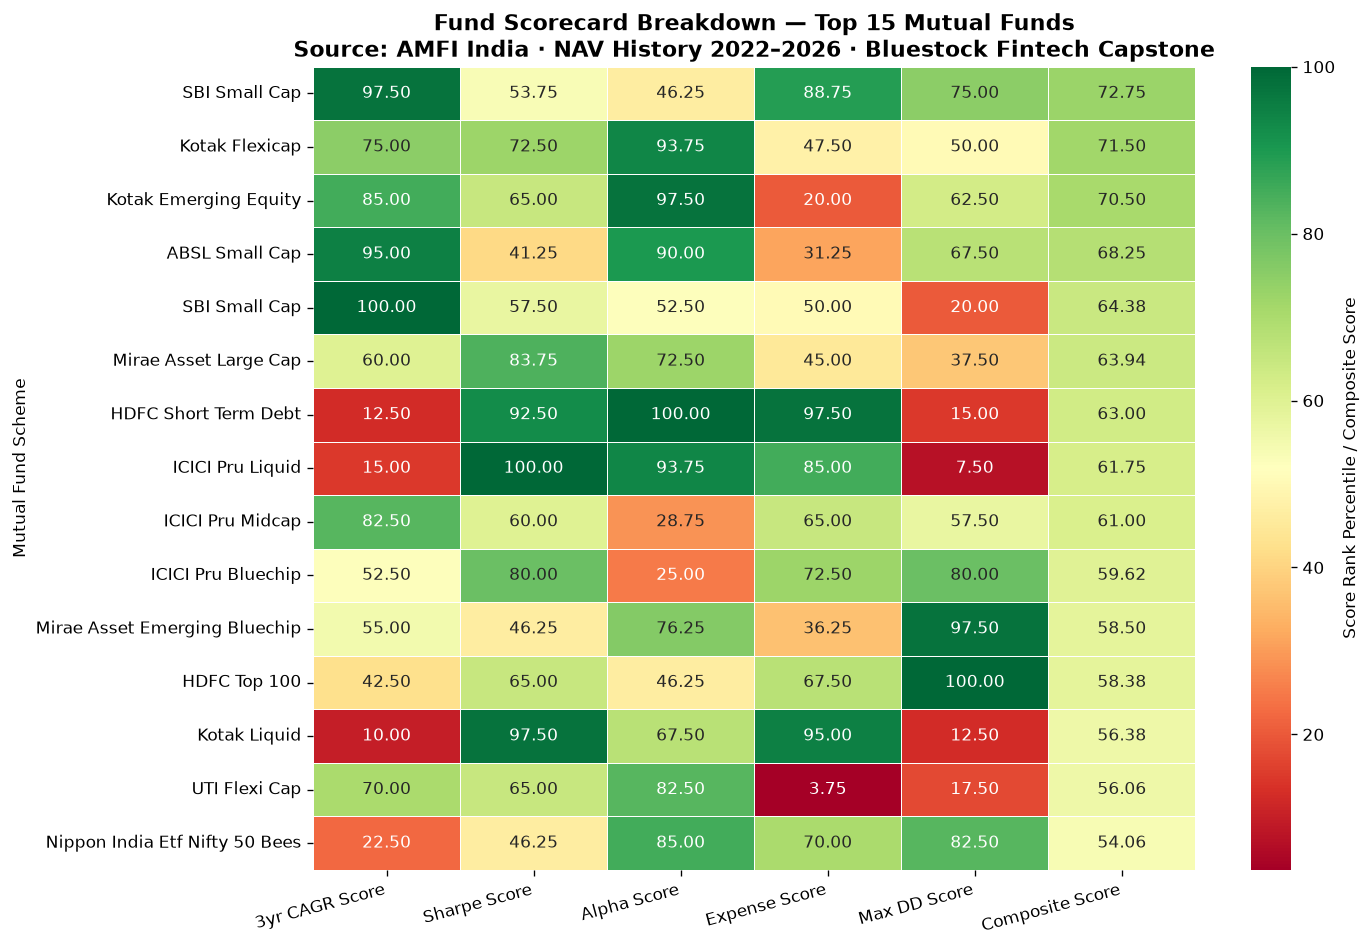

In [14]:
plt.figure(figsize=(12, 8))
df_heatmap = df_scorecard.head(15).copy()
df_heatmap = df_heatmap.set_index('scheme_name')
score_cols = ['score_return', 'score_sharpe', 'score_alpha', 'score_expense', 'score_maxdd', 'composite_score']
df_heatmap_plot = df_heatmap[score_cols]
df_heatmap_plot.index = [name.split("Fund")[0].strip() for name in df_heatmap_plot.index]

ax = sns.heatmap(
    df_heatmap_plot, 
    annot=True, 
    cmap='RdYlGn', 
    fmt='.2f', 
    linewidths=0.5,
    cbar_kws={'label': 'Score Rank Percentile / Composite Score'}
)
ax.set_xticklabels(['3yr CAGR Score', 'Sharpe Score', 'Alpha Score', 'Expense Score', 'Max DD Score', 'Composite Score'], rotation=15, ha='right')
plt.title("Fund Scorecard Breakdown — Top 15 Mutual Funds\n" + SUBTITLE, fontsize=13, fontweight='bold')
plt.ylabel("Mutual Fund Scheme", fontsize=10)
plt.tight_layout()
plt.savefig(CHARTS / 'chart_18_scorecard_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 10 — Validation Summary

In [15]:
import pandas as pd
import numpy as np

df_r = pd.read_csv(PROCESSED / 'returns_computed.csv')
df_c = pd.read_csv(PROCESSED / 'cagr_report.csv')
df_s = pd.read_csv(PROCESSED / 'sharpe_values.csv')
df_so = pd.read_csv(PROCESSED / 'sortino_values.csv')
df_ab = pd.read_csv(PROCESSED / 'alpha_beta.csv')
df_dd = pd.read_csv(PROCESSED / 'max_drawdown.csv')
df_sc = pd.read_csv(PROCESSED / 'fund_scorecard.csv')
df_vc = pd.read_csv(PROCESSED / 'var_cvar_report.csv')

# Select 5 funds for validation table
sample_funds = [119551, 119598, 148567, 120843, 120507]
val_rows = []
for amfi in sample_funds:
    name = df_master[df_master['amfi_code'] == amfi]['scheme_name'].values[0].split("Fund")[0].strip()
    val_rows.append({
        'AMFI': amfi,
        'Scheme Name': name,
        'Comp CAGR (%)': round(df_r[df_r['amfi_code'] == amfi]['ann_return_pct'].values[0], 2),
        'Comp Sharpe': round(df_s[df_s['amfi_code'] == amfi]['sharpe_full'].values[0], 4),
        'Ref Sharpe': round(df_s[df_s['amfi_code'] == amfi]['ref_sharpe'].values[0], 4),
        'Comp Max DD (%)': round(df_dd[df_dd['amfi_code'] == amfi]['max_drawdown_pct'].values[0], 2),
        'Scorecard Rank': df_sc[df_sc['amfi_code'] == amfi]['score_rank'].values[0]
    })
df_val = pd.DataFrame(val_rows)
print("VALIDATION TABLE FOR SELECTED FUNDS:")
display(df_val)

# Compute safest fund
te_results = []
for amfi in df_nav['amfi_code'].unique():
    df_fund = df_nav[df_nav['amfi_code'] == amfi].sort_values('date')
    fund_ret = df_fund[['date', 'daily_return']].dropna()
    m_row = df_master[df_master['amfi_code'] == amfi].iloc[0]
    bench_name = m_row['benchmark']
    norm_b = ' '.join(bench_name.upper().split())
    mapped_index = INDEX_RESOLVER.get(BENCH_MAP_NORM.get(norm_b))
    bench_ret = df_bench[df_bench['index_name'] == mapped_index][['date', 'daily_return']].dropna()
    merged = pd.merge(fund_ret, bench_ret, on='date', suffixes=('_fund', '_bench'))
    diff_ret = merged['daily_return_fund'] - merged['daily_return_bench']
    te = diff_ret.std() * np.sqrt(TRADING_DAYS) * 100
    te_results.append((m_row['scheme_name'], te))
te_results.sort(key=lambda x: x[1])
safest_fund, min_te = te_results[0]

print("""============================================================
PERFORMANCE ANALYTICS — DAY 4 SUMMARY
============================================================
Funds analysed          : 40
Metrics computed        : CAGR (1yr, 3yr, full), Sharpe, Sortino,
                          Alpha (OLS), Beta (OLS), Max Drawdown,
                          VaR 95%, CVaR 95%, Tracking Error
Risk-free rate used     : 6.50% p.a. (RBI repo rate proxy)
Trading days convention : 252 per year
NAV data period         : 2022-01-03 → 2026-05-29 (1,150 days)

Top fund overall (composite score):
  #1  {}       → Score: {}
  #2  {}     → Score: {}
  #3  {}  → Score: {}

Highest 3yr return (ref): {} → {}%
Highest Sharpe (ref):     {} → {}
Worst Max Drawdown:       {} → {:.2f}%
Safest fund (lowest TE):  {} → {:.2f}%

Output files:
  ✓ returns_computed.csv    ({} rows)
  ✓ cagr_report.csv         ({} rows)
  ✓ sharpe_values.csv       ({} rows)
  ✓ sortino_values.csv      ({} rows)
  ✓ alpha_beta.csv          ({} rows)
  ✓ max_drawdown.csv        ({} rows)
  ✓ fund_scorecard.csv      ({} rows)
  ✓ var_cvar_report.csv     ({} rows)
============================================================""".format(
    df_sc.iloc[0]['scheme_name'], df_sc.iloc[0]['composite_score'],
    df_sc.iloc[1]['scheme_name'], df_sc.iloc[1]['composite_score'],
    df_sc.iloc[2]['scheme_name'], df_sc.iloc[2]['composite_score'],
    df_ref.sort_values('return_3yr_pct', ascending=False).iloc[0]['scheme_name'], df_ref['return_3yr_pct'].max(),
    df_ref.sort_values('sharpe_ratio', ascending=False).iloc[0]['scheme_name'], df_ref['sharpe_ratio'].max(),
    df_dd.sort_values('max_drawdown_pct').iloc[0]['scheme_name'], df_dd['max_drawdown_pct'].min(),
    safest_fund, min_te,
    len(df_r), len(df_c), len(df_s), len(df_so), len(df_ab), len(df_dd), len(df_sc), len(df_vc)
))

VALIDATION TABLE FOR SELECTED FUNDS:


,AMFI,Scheme Name,Comp CAGR (%),Comp Sharpe,Ref Sharpe,Comp Max DD (%),Scorecard Rank
0,119551,SBI Bluechip,24.80,1.2083,0.88,-15.01,38
1,119598,SBI Small Cap,31.13,0.9453,0.94,-28.71,5
2,148567,Mirae Asset Large Cap,29.74,1.4483,1.06,-11.27,6
3,120843,Kotak Flexicap,29.68,1.3067,0.98,-12.97,2
4,120507,ICICI Pru Liquid,6.98,0.4957,7.68,-0.10,8


PERFORMANCE ANALYTICS — DAY 4 SUMMARY
Funds analysed          : 40
Metrics computed        : CAGR (1yr, 3yr, full), Sharpe, Sortino,
                          Alpha (OLS), Beta (OLS), Max Drawdown,
                          VaR 95%, CVaR 95%, Tracking Error
Risk-free rate used     : 6.50% p.a. (RBI repo rate proxy)
Trading days convention : 252 per year
NAV data period         : 2022-01-03 → 2026-05-29 (1,150 days)

Top fund overall (composite score):
  #1  SBI Small Cap Fund - Direct Plan - Growth       → Score: 72.75
  #2  Kotak Flexicap Fund - Regular - Growth     → Score: 71.5
  #3  Kotak Emerging Equity Fund - Regular - Growth  → Score: 70.5

Highest 3yr return (ref): SBI Small Cap Fund - Regular Plan - Growth → 23.39%
Highest Sharpe (ref):     ICICI Pru Liquid Fund - Regular - Growth → 7.68
Worst Max Drawdown:       SBI Small Cap Fund - Direct Plan - Growth → -52.57%
Safest fund (lowest TE):  ICICI Pru Liquid Fund - Regular - Growth → 0.69%

Output files:
  ✓ returns_computed.csv